Ноутбук `exp01_eda_baseline.ipynb` предназначен для равзедовочного анализа данных (EDA)  синтетически сгенерированного набора данных, а также для обучения `baseline` и получения его метрик, для дальнейшего сравнения с основной моделью `DeepPavlov/rubert-base-cased-conversational` с дополнитльным fine-tuning. 

In [40]:
import pandas as pd
import torch 
import random 
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay
import joblib
import yaml

BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebooks":
    BACKEND_DIR = BASE_DIR.parent
elif BASE_DIR.name == "backend":
    BACKEND_DIR = BASE_DIR
else:
    BACKEND_DIR = BASE_DIR / "backend"

DIRECTORIES_CONFIG_PATH = BACKEND_DIR / "configs" / "directories.yaml"

with DIRECTORIES_CONFIG_PATH.open("r", encoding="utf-8") as file:
    directories_config = yaml.safe_load(file)

def configured_path(name: str) -> Path:
    return (BACKEND_DIR / directories_config["paths"][name]).resolve()

DATASET_PATH = configured_path("dataset")
EXP01_DIR = configured_path("exp01_dir")
EXP01_FIGURES_DIR = configured_path("exp01_figures_dir")
EXP01_MODELS_DIR = configured_path("exp01_models_dir")

EXP01_DIR.mkdir(parents=True, exist_ok=True)
EXP01_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXP01_MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(BACKEND_DIR / "configs" / "exp01_config.yaml", "r", encoding="utf-8") as file:
    exp01_config = yaml.safe_load(file)
    
RANDOM_STATE = exp01_config["random_state"]

test_size = exp01_config["split"]["test_size"]
validation_size = exp01_config["split"]["validation_size"]

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [41]:
df = pd.read_csv(DATASET_PATH, sep=";")


df.head()

,ID,text,label
0,1,"Регулярный платёж списался частично, остаток в...",PAYMENT_OUT_FAIL
1,2,задержка по кэшбэку уже 9 рабочих дней когда н...,INCOMING_DELAY
2,3,Face ID крутится и возвращает на экран логина....,APP_LOGIN
3,4,аналитика расходов крутится бесконечно данных ...,APP_TECH
4,5,звонили представились банком просили код ничег...,FRAUD_SUSPECTED


In [42]:
print('Баланс классов:\n')
print(df["label"].value_counts())
print('\n-------------\n\n')
print('Базовая информация о наборе данных:')
print(df.info())
print('\n-------------\n\n')
print('Длина встречающихся обращений:')
print(df["text"].str.len().describe())
print('\n-------------\n\n')
print('Кол-во дубликатов:')
print(df.duplicated().sum())
print('\n-------------\n\n')
print('Количество нулей:')
print(df.isna().sum())

Баланс классов:

label
PAYMENT_OUT_FAIL    131
INCOMING_DELAY      131
APP_LOGIN           131
CARD_ISSUE          129
ACCOUNT_SEIZED      129
FRAUD_SUSPECTED     124
KYC_VERIFICATION    124
APP_TECH            101
Name: count, dtype: int64

-------------


Базовая информация о наборе данных:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ID      1000 non-null   int64
 1   text    1000 non-null   str  
 2   label   1000 non-null   str  
dtypes: int64(1), str(2)
memory usage: 146.1 KB
None

-------------


Длина встречающихся обращений:
count    1000.000000
mean       61.156000
std        11.188156
min        38.000000
25%        53.000000
50%        59.000000
75%        67.000000
max       107.000000
Name: text, dtype: float64

-------------


Кол-во дубликатов:
0

-------------


Количество нулей:
ID       0
text     0
label    0
dtype: int64


In [43]:
train_df, test_df = train_test_split(
    df,
    test_size=test_size,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=test_size,
    random_state=RANDOM_STATE,
    stratify=train_df["label"],
)

print(train_df.shape, val_df.shape, test_df.shape)

print("\nРаспределение классов в train:")
print(train_df["label"].value_counts())

print("Распределение классов в validation:")
print(val_df["label"].value_counts())

print("Распределение классов в test:")
print(test_df["label"].value_counts())

(562, 3) (188, 3) (250, 3)

Распределение классов в train:
label
ACCOUNT_SEIZED      73
CARD_ISSUE          73
APP_LOGIN           73
INCOMING_DELAY      73
PAYMENT_OUT_FAIL    73
FRAUD_SUSPECTED     70
KYC_VERIFICATION    70
APP_TECH            57
Name: count, dtype: int64
Распределение классов в validation:
label
APP_LOGIN           25
INCOMING_DELAY      25
PAYMENT_OUT_FAIL    25
ACCOUNT_SEIZED      24
CARD_ISSUE          24
FRAUD_SUSPECTED     23
KYC_VERIFICATION    23
APP_TECH            19
Name: count, dtype: int64
Распределение классов в test:
label
APP_LOGIN           33
INCOMING_DELAY      33
PAYMENT_OUT_FAIL    33
CARD_ISSUE          32
ACCOUNT_SEIZED      32
FRAUD_SUSPECTED     31
KYC_VERIFICATION    31
APP_TECH            25
Name: count, dtype: int64


In [44]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer=exp01_config["tfidf"]["analyzer"],
        max_features=exp01_config["tfidf"]['max_feauters'],
        ngram_range=tuple(exp01_config["tfidf"]["ngram_range"]),
        lowercase=True,
    )),
    ("classifier", LogisticRegression(
        max_iter=exp01_config["logistic_regression"]["max_iter"],
        class_weight=exp01_config["logistic_regression"]["class_weight"],
        random_state=RANDOM_STATE,
    )),
])

baseline_model.fit(train_df["text"], train_df["label"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [45]:
val_preds = baseline_model.predict(val_df['text'])

val_accuracy = accuracy_score(val_df['label'], val_preds)
val_f1_macro = f1_score(val_df['label'], val_preds, average='macro')
val_f1_weighted = f1_score(val_df['label'], val_preds, average='weighted')

val_metrics = {
    "val_accuracy": val_accuracy,
    "val_f1_macro": val_f1_macro,
    "val_f1_weighted": val_f1_weighted,
}

print(val_metrics)
print(classification_report(val_df["label"], val_preds))

{'val_accuracy': 0.9308510638297872, 'val_f1_macro': 0.930536229766106, 'val_f1_weighted': 0.9310978758413051}
                  precision    recall  f1-score   support

  ACCOUNT_SEIZED       0.96      0.96      0.96        24
       APP_LOGIN       0.85      0.92      0.88        25
        APP_TECH       0.89      0.89      0.89        19
      CARD_ISSUE       0.96      0.96      0.96        24
 FRAUD_SUSPECTED       1.00      0.91      0.95        23
  INCOMING_DELAY       0.96      1.00      0.98        25
KYC_VERIFICATION       0.95      0.91      0.93        23
PAYMENT_OUT_FAIL       0.88      0.88      0.88        25

        accuracy                           0.93       188
       macro avg       0.93      0.93      0.93       188
    weighted avg       0.93      0.93      0.93       188



In [46]:
test_preds = baseline_model.predict(test_df['text'])

test_accuracy = accuracy_score(test_df['label'], test_preds)
test_f1_macro = f1_score(test_df['label'], test_preds, average='macro')
test_f1_weighted = f1_score(test_df['label'], test_preds, average='weighted')

test_metrics = {
    "test_accuracy": test_accuracy,
    "test_f1_macro": test_f1_macro,
    "test_f1_weighted": test_f1_weighted,
}

print(test_metrics)
print(classification_report(test_df["label"], test_preds))

{'test_accuracy': 0.932, 'test_f1_macro': 0.933120226779001, 'test_f1_weighted': 0.932204063956237}
                  precision    recall  f1-score   support

  ACCOUNT_SEIZED       1.00      0.88      0.93        32
       APP_LOGIN       0.89      0.94      0.91        33
        APP_TECH       1.00      0.92      0.96        25
      CARD_ISSUE       0.91      1.00      0.96        32
 FRAUD_SUSPECTED       0.93      0.87      0.90        31
  INCOMING_DELAY       1.00      0.97      0.98        33
KYC_VERIFICATION       0.94      1.00      0.97        31
PAYMENT_OUT_FAIL       0.83      0.88      0.85        33

        accuracy                           0.93       250
       macro avg       0.94      0.93      0.93       250
    weighted avg       0.94      0.93      0.93       250



<Figure size 1000x800 with 0 Axes>

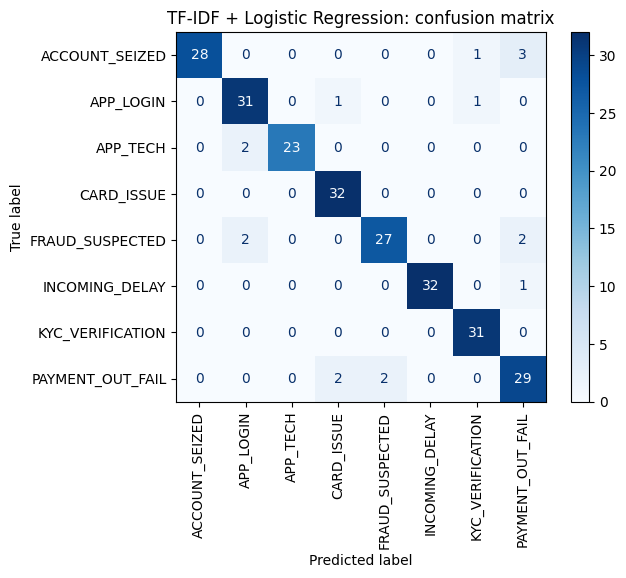

In [47]:
labels = sorted(df['label'].unique())

conf_matr = confusion_matrix(test_df['label'], test_preds, labels=labels)

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matr, display_labels=labels)
disp.plot(xticks_rotation=90, cmap="Blues", values_format="d")
plt.title("TF-IDF + Logistic Regression: confusion matrix")
plt.savefig(configured_path("exp01_confusion_matrix"), dpi=300, bbox_inches="tight")
plt.show()

In [48]:

joblib.dump(baseline_model, configured_path("exp01_baseline_model"))

['/Users/ruslanhincagov/Desktop/AppealClassificationApp/backend/artifacts/exp01_baseline/models/baseline_tfidf_logreg.joblib']

In [49]:
loaded_baseline = joblib.load(configured_path("exp01_baseline_model"))
loaded_baseline.predict([
    "Не работает сотрудник не хочет делать работу помогите"
])

array(['CARD_ISSUE'], dtype=object)